In [19]:

import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel, AutoModel
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import pandas as pd
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"  # Fix Hugging Face warning



In [20]:


from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained(
    '/kaggle/input/base-model-indobertweet/transformers/default/1/base-model-indobertweet'
)
model = AutoModel.from_pretrained("/kaggle/input/base-model-indobertweet/transformers/default/1/base-model-indobertweet")
# tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")
# model = AutoModel.from_pretrained("indolem/indobertweet-base-uncased")

In [ ]:
# List available physical GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable dynamic memory growth (prevents TensorFlow from reserving all VRAM)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Using GPU: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected, training will use CPU instead.")

In [21]:
# =============================================
# IndoBERTweet + BiLSTM for Binary Classification (PyTorch)
# =============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_json('/kaggle/input/fetched-data-final-2/fetched_data_final_dedup.json')
X = df['text'].tolist()
y = df['label'].astype(int).tolist()

# -------------------------------
# 2. Load IndoBERTweet
# -------------------------------
bert_model = model

# -------------------------------
# 3. Configuration
# -------------------------------
max_length = 128
batch_size = 16
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# -------------------------------
# 4. Dataset class
# -------------------------------
class IndoDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }

# -------------------------------
# 5. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_dataset = IndoDataset(X_train, y_train, tokenizer, max_length)
test_dataset = IndoDataset(X_test, y_test, tokenizer, max_length)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# -------------------------------
# 6. Define model (IndoBERTweet + BiLSTM)
# -------------------------------
class IndoBERTweetBiLSTM(nn.Module):
    def __init__(self, bert_model):
        super(IndoBERTweetBiLSTM, self).__init__()
        self.bert = bert_model
        self.lstm = nn.LSTM(input_size=768, hidden_size=64, num_layers=1, 
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64 * 2 * max_length, 1)  # Flattened features
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # Freeze IndoBERTweet (feature-based)
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
        lstm_out, _ = self.lstm(last_hidden_state)
        x = self.dropout(lstm_out)
        x = x.contiguous().view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return self.sigmoid(x)

model = IndoBERTweetBiLSTM(bert_model).to(device)

# -------------------------------
# 7. Define optimizer and loss
# -------------------------------
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
best_val_loss = float('inf')
patience = 3  # stop if no improvement after 3 epochs
patience_counter = 0
best_model_path = "/kaggle/working/best_indobertweet_bilstm_model.pt"
# accuracy_metric = BinaryAccuracy().to(device)
# precision_metric = BinaryPrecision().to(device)
# recall_metric = BinaryRecall().to(device)
# f1_metric = BinaryF1Score().to(device)

# Tracking for plotting
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_prec": [],
    "val_rec": [],
    "val_f1": []
}

# -------------------------------
# 8. Training loop
# -------------------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)
    # print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

    # -------------------------------
    # Validation
    # -------------------------------
    model.eval()
    val_loss, y_true, y_pred = 0.0, [], []
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].unsqueeze(1).to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (outputs > 0.5).float().cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)
            # all_preds.append(preds)
            # all_labels.append(labels)

    avg_val_loss = val_loss / len(test_loader)
    val_acc = accuracy_score(y_true, y_pred)
    val_prec = precision_score(y_true, y_pred, average='macro')
    val_rec = recall_score(y_true, y_pred, average='macro')
    val_f1 = f1_score(y_true, y_pred, average='macro')

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_prec"].append(val_prec)
    history["val_rec"].append(val_rec)
    history["val_f1"].append(val_f1)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"| Train Loss: {avg_train_loss:.4f} "
          f"| Val Loss: {avg_val_loss:.4f} "
          f"| Acc: {val_acc:.4f} "
          f"| Prec: {val_prec:.4f} "
          f"| Rec: {val_rec:.4f} "
          f"| F1: {val_f1:.4f}")


    # -------------------------------
    # Early Stopping logic
    # -------------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Model improved and saved at epoch {epoch+1}")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement for {patience_counter} epoch(s)")
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break


✅ Using device: cuda
Epoch [1/20] | Train Loss: 0.5164 | Val Loss: 0.3804 | Acc: 0.8260 | Prec: 0.8259 | Rec: 0.8258 | F1: 0.8259
✅ Model improved and saved at epoch 1
Epoch [2/20] | Train Loss: 0.3669 | Val Loss: 0.3137 | Acc: 0.8658 | Prec: 0.8658 | Rec: 0.8655 | F1: 0.8656
✅ Model improved and saved at epoch 2
Epoch [3/20] | Train Loss: 0.3175 | Val Loss: 0.2872 | Acc: 0.8786 | Prec: 0.8785 | Rec: 0.8785 | F1: 0.8785
✅ Model improved and saved at epoch 3
Epoch [4/20] | Train Loss: 0.2863 | Val Loss: 0.2726 | Acc: 0.8837 | Prec: 0.8836 | Rec: 0.8838 | F1: 0.8837
✅ Model improved and saved at epoch 4
Epoch [5/20] | Train Loss: 0.2702 | Val Loss: 0.2665 | Acc: 0.8914 | Prec: 0.8916 | Rec: 0.8911 | F1: 0.8913
✅ Model improved and saved at epoch 5
Epoch [6/20] | Train Loss: 0.2598 | Val Loss: 0.2556 | Acc: 0.8965 | Prec: 0.8965 | Rec: 0.8968 | F1: 0.8965
✅ Model improved and saved at epoch 6
Epoch [7/20] | Train Loss: 0.2442 | Val Loss: 0.2519 | Acc: 0.8991 | Prec: 0.8990 | Rec: 0.8991 |

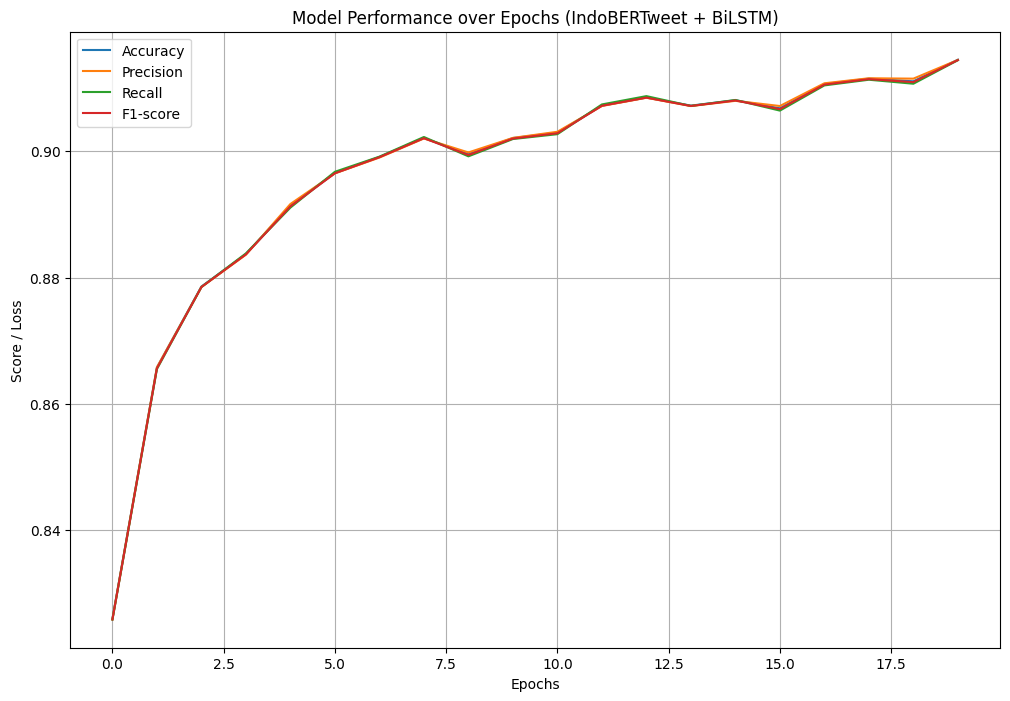

In [23]:
# -------------------------------
# 9. Plot performance
# -------------------------------
plt.figure(figsize=(12, 8))
plt.plot(history["val_acc"], label="Accuracy")
plt.plot(history["val_prec"], label="Precision")
plt.plot(history["val_rec"], label="Recall")
plt.plot(history["val_f1"], label="F1-score")
# plt.plot(history["val_loss"], label="Validation Loss", linestyle="--")
plt.title("Model Performance over Epochs (IndoBERTweet + BiLSTM)")
plt.xlabel("Epochs")
plt.ylabel("Score / Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# -------------------------------
# 9. Evaluation
# -------------------------------
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        outputs = model(input_ids, attention_mask)
        preds = (outputs > 0.5).float().cpu().numpy()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\n✅ Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# -------------------------------
# 10. Save model
# -------------------------------
torch.save(model.state_dict(), "/kaggle/working/indobertweet_bilstm_model.pt")
print("\n💾 Model saved successfully!")



Classification Report:
              precision    recall  f1-score   support

         0.0     0.9130    0.9114    0.9122      1140
         1.0     0.9159    0.9174    0.9167      1199

    accuracy                         0.9145      2339
   macro avg     0.9145    0.9144    0.9144      2339
weighted avg     0.9145    0.9145    0.9145      2339


Confusion Matrix:
[[1039  101]
 [  99 1100]]

✅ Test Accuracy: 0.9145

💾 Model saved successfully!


In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix

# # Predictions
# y_pred = (model.predict([X_test_input_ids, X_test_attention]) > 0.5).astype("int32")

# # Reports
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))